#### Regional Trends: Gain, Loss and Net Change Diverging Bar Chart
- Bar charts will show percentage change in Deciduous Woodland (DW) area across International Territorial Level 1 (ITL1) regions in England and Wales between 1990 and 2024.
- Values will be calculated relative to baseline levels of DW recorded in 1990.

In [1]:
# Importing required packages
import pandas as pd
import numpy as np
import os
from pathlib import Path

# Importing localised file directory
project_root = Path(os.environ['marsh_tit_project'])

# Importing regional data
r_gain = pd.read_csv(project_root/'ukceh'/'custom'/'regional_analysis'/'regional_gain.csv')
r_loss = pd.read_csv(project_root/'ukceh'/'custom'/'regional_analysis'/'regional_loss.csv')
r_net = pd.read_csv(project_root/'ukceh'/'custom'/'regional_analysis'/'regional_net_change.csv')

# Importing regional deciduous land cover in 1990
lc_1990 = pd.read_csv(project_root/'ukceh'/'custom'/'regional_analysis'/'regional_deciduous_1990.csv')

#### Calculating Regional Area (Total) and Regional Deciduous Area

In [2]:
# Land Cover 1990
r_lc_1990 = lc_1990[['ITL125NM', '_count','_sum']] # filtering columns

# Converting 1990 pixel counts into area [km^2]
r_lc_1990['deciduous_area_1990'] = r_lc_1990['_sum']*0.025*0.025 # deciduous area
r_lc_1990['regional_area'] = r_lc_1990['_count']*0.025*0.025 # total regional area
r_lc_1990 = r_lc_1990.drop(columns=['_sum', '_count']) # removing redundant columns

# Converting regional gain pixel counts into area [km^2]
r_gain = r_gain[['ITL125NM', '_sum']] # filtering columns
r_gain['area_gain'] = r_gain['_sum']*0.025*0.025 # deciduous area gained
r_gain = r_gain.drop(columns=['_sum']) # removing redundant column

# Converting regional loss pixel counts into area [km^2]
r_loss = r_loss[['ITL125NM', '_sum']] # filtering columns
r_loss['area_loss'] = r_loss['_sum']*0.025*0.025 # deciduous area lost
r_loss = r_loss.drop(columns=['_sum']) # removing redundant column

# Converting regional net change pixel counts into area [km^2]
r_net = r_net[['ITL125NM', '_sum']] # filtering columns
r_net['area_net'] = r_net['_sum']*0.025*0.025 # Net change in deciduous area
r_net = r_net.drop(columns=['_sum']) # removing redundant column

C:\Users\amman\AppData\Local\Temp\ipykernel_2020\1045659917.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r_lc_1990['deciduous_area_1990'] = r_lc_1990['_sum']*0.025*0.025 # deciduous area
C:\Users\amman\AppData\Local\Temp\ipykernel_2020\1045659917.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r_lc_1990['regional_area'] = r_lc_1990['_count']*0.025*0.025 # total regional area


#### Joining regional loss, gain and net change into a single DataFrame

In [3]:
r_lcc = (
    r_lc_1990
    .merge(r_gain, how='inner', on='ITL125NM')
    .merge(r_loss, how='inner', on='ITL125NM')
    .merge(r_net, how='inner', on='ITL125NM')
)

#### Calculating relative gross loss, relative gross gain, relative net change (%)

In [4]:
# Gain
r_lcc['%_gain'] = (
    round((r_lcc['area_gain'] / r_lcc['deciduous_area_1990'])*100,2)
)

# Loss
r_lcc['%_loss'] = (
    round((r_lcc['area_loss'] / r_lcc['deciduous_area_1990'])*100,2)
)

# Net Change
r_lcc['%_net'] = (
    round((r_lcc['area_net'] / r_lcc['deciduous_area_1990'])*100,2)
)

#### Cleaning string data: Removing '(England)' from ITL125NM records

In [5]:
r_lcc['ITL125NM'] = r_lcc['ITL125NM'].str.replace(' (England)', '')

#### Adding red colour gradient to gross loss bar chart

In [6]:
# Normalising loss values between 0 and 1
from matplotlib.colors import Normalize as norm
import matplotlib.pyplot as plt
normalise_loss = norm(vmin=r_lcc['%_loss'].min(), vmax=r_lcc['%_loss'].max())

# Using normalised values to set up colour gradient for loss
cg_loss = []
for values in r_lcc['%_loss'].sort_values(ascending=False):
    cg_loss.append(plt.cm.Reds(normalise_loss(values)))

#### Adding green colour gradient to gross gain bar chart

In [7]:
# Normalising gain values between 0 and 1
normalise_gain = norm(vmin=r_lcc['%_gain'].min(), vmax=r_lcc['%_gain'].max())

# Using normalised values to set up colour gradient for gain
cg_gain = []
for values in r_lcc['%_gain'].sort_values(ascending=False):
    cg_gain.append(plt.cm.Greens(normalise_gain(values)))

#### Adding green colour gradient to net change bar chart

In [8]:
# Normalising net change values between 0 and 1
normalise_net = norm(vmin=r_lcc['%_net'].min(), vmax=r_lcc['%_net'].max())

# Using normalised values to set up colour gradient for net change
cg_net = []
for values in r_lcc['%_net'].sort_values(ascending=False):
    cg_net.append(plt.cm.Greens(normalise_net(values)))

#### Creating gross loss bar chart

C:\Users\amman\AppData\Local\Temp\ipykernel_2020\1261047478.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  loss_bar = sns.barplot(data=r_lcc,


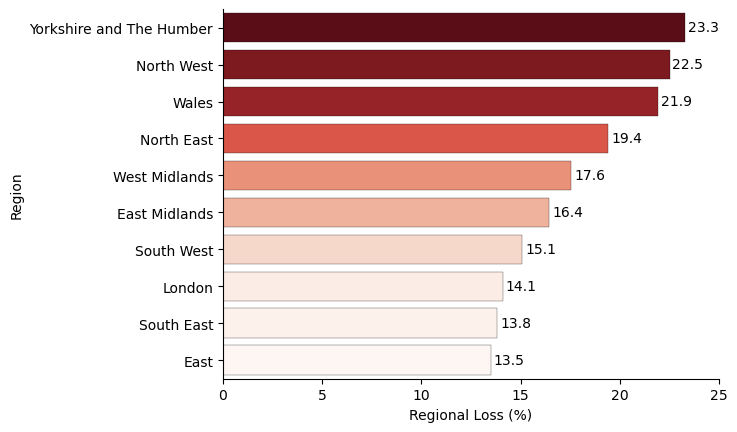

In [9]:
# Import required package
import seaborn as sns

# To correctly apply colour gradient, records must be sorted in descending order
loss_order = (r_lcc.sort_values('%_loss', ascending=False)['ITL125NM'])

loss_bar = sns.barplot(data=r_lcc,
                       x='%_loss',
                       y='ITL125NM',
                       palette=cg_loss, # colour gradient
                       order=loss_order,
                      edgecolor='black',
                      linewidth=0.2)

loss_bar.set_ylabel('Region')
loss_bar.set_xlabel('Regional Loss (%)')
loss_bar.set_xlim(0, 25)

sns.despine(top=True,
            right=True) # removes top and right border of figure

for container in loss_bar.containers:
    loss_bar.bar_label(container,
                       fmt='%.1f', # 1 decimal place
                   padding=2) # spacing of label to bar

# Exporting figure
plt.savefig(project_root/'gis_marsh_tit'/'project_pics'/'regional_loss_bar', 
            dpi=300, 
            bbox_inches='tight')
plt.show()

#### Creating gross gain bar chart

C:\Users\amman\AppData\Local\Temp\ipykernel_2020\2727313759.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  gain_bar = sns.barplot(data=r_lcc,


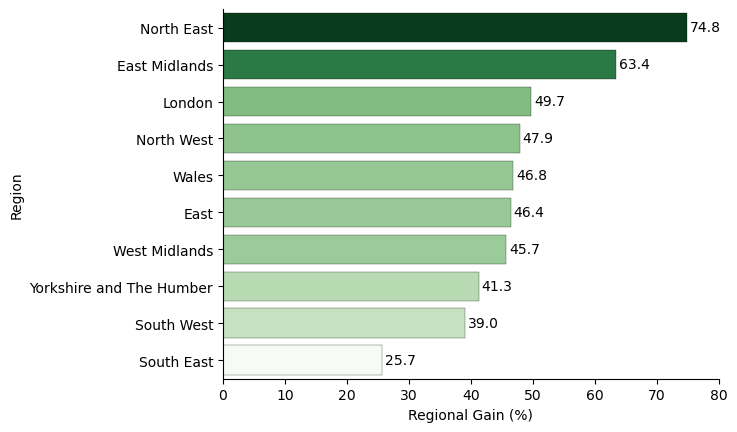

In [10]:
# To correctly apply colour gradient, records must be sorted in descending order
gain_order = r_lcc.sort_values('%_gain', ascending=False)['ITL125NM']

gain_bar = sns.barplot(data=r_lcc,
                       x='%_gain',
                       y='ITL125NM',
                       palette=cg_gain, # colour gradient
                       order=gain_order,
                      edgecolor='black',
                      linewidth=0.2)

gain_bar.set_ylabel('Region')
gain_bar.set_xlabel('Regional Gain (%)')
gain_bar.set_xlim(0, 80)

sns.despine(top=True,
            right=True) # removes top and right border of figure

for container in gain_bar.containers:
    gain_bar.bar_label(container,
                       fmt='%.1f', # 1 decimal place
                   padding=2) # spacing of label to bar

# Exporting figure
plt.savefig(project_root/'gis_marsh_tit'/'project_pics'/'regional_gain_bar', 
            dpi=300, 
            bbox_inches='tight')
plt.show()

#### Creating Net Change bar chart

C:\Users\amman\AppData\Local\Temp\ipykernel_2020\2439862431.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  net_bar = sns.barplot(data=r_lcc,


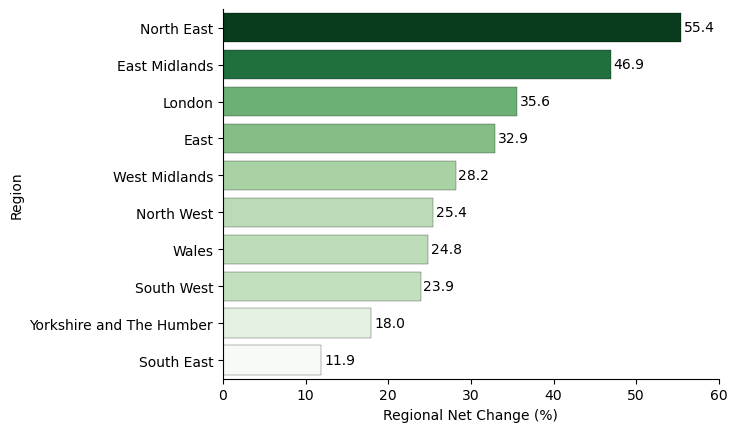

In [11]:
# To correctly apply colour gradient, records must be sorted in descending order
net_order = r_lcc.sort_values('%_net', ascending=False)['ITL125NM']

net_bar = sns.barplot(data=r_lcc,
                      x='%_net',
                      y='ITL125NM',
                      order=net_order,
                     palette=cg_net, # colour gradient
                     edgecolor='black',
                     linewidth=0.2)

net_bar.set_ylabel('Region')
net_bar.set_xlabel('Regional Net Change (%)')
net_bar.set_xlim(0, 60)

sns.despine(top=True,
            right=True) # removes top and right border of figure

for container in net_bar.containers:
    net_bar.bar_label(container,
                       fmt='%.1f', # 1 decimal place
                   padding=2) # spacing of label to bar

# Exporting figure
plt.savefig(project_root/'gis_marsh_tit'/'project_pics'/'regional_net_change_bar', 
            dpi=300, 
            bbox_inches='tight')
plt.show()